In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/home/puru/Documents/House Price Prediction/STEP - 2 (Data Cleaning)/5 - Missing Value/gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3514, 20)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,malibu towne,sector 47,2.40,10000.0,3,3,0,0.0,Moderately Old,2992.86,2667.0,2400.03,0,0,0,0,0,1,22
1,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,3,3,3,2.0,Relatively New,1650.00,1524.0,1399.95,1,1,0,0,0,1,136
2,flat,puri diplomatic greens,sector 111,2.25,13235.0,3,3,2,12.0,Relatively New,1700.05,1539.0,1385.00,0,0,0,0,0,0,101
3,flat,signature andour heights,sector 71,0.60,10000.0,2,2,1,5.0,Relatively New,599.98,557.0,513.98,0,0,0,1,0,0,59
4,flat,bestech park view residency,sector 2,1.40,7865.0,3,3,3+,8.0,Moderately Old,1780.03,1611.0,1450.00,0,0,0,0,0,0,92


In [6]:
train_df = df.drop(columns=['society','price_per_sqft','built_up_area','carpet_area'])

In [7]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,super_built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 47,2.40,3,3,0,0.0,Moderately Old,2992.86,0,0,0,0,0,1,22
1,flat,sector 65,2.36,3,3,3,2.0,Relatively New,1650.00,1,1,0,0,0,1,136
2,flat,sector 111,2.25,3,3,2,12.0,Relatively New,1700.05,0,0,0,0,0,0,101
3,flat,sector 71,0.60,2,2,1,5.0,Relatively New,599.98,0,0,0,1,0,0,59
4,flat,sector 2,1.40,3,3,3+,8.0,Moderately Old,1780.03,0,0,0,0,0,0,92


## `1.` luxury score

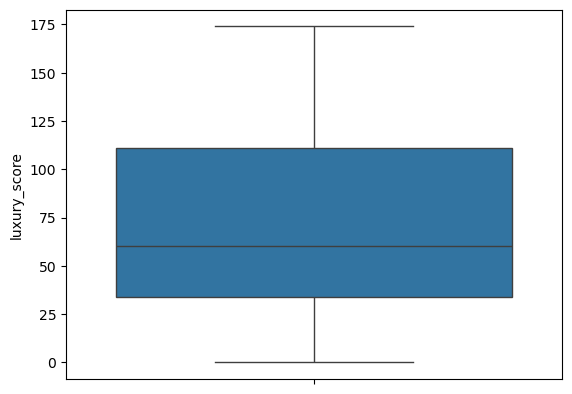

In [8]:
sns.boxplot(df['luxury_score'])
plt.show()

In [9]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None 

In [10]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [11]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,super_built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 47,2.40,3,3,0,0.0,Moderately Old,2992.86,0,0,0,0,0,1,22,Low
1,flat,sector 65,2.36,3,3,3,2.0,Relatively New,1650.00,1,1,0,0,0,1,136,Medium
2,flat,sector 111,2.25,3,3,2,12.0,Relatively New,1700.05,0,0,0,0,0,0,101,Medium
3,flat,sector 71,0.60,2,2,1,5.0,Relatively New,599.98,0,0,0,1,0,0,59,Medium
4,flat,sector 2,1.40,3,3,3+,8.0,Moderately Old,1780.03,0,0,0,0,0,0,92,Medium


## `2.` floorNum

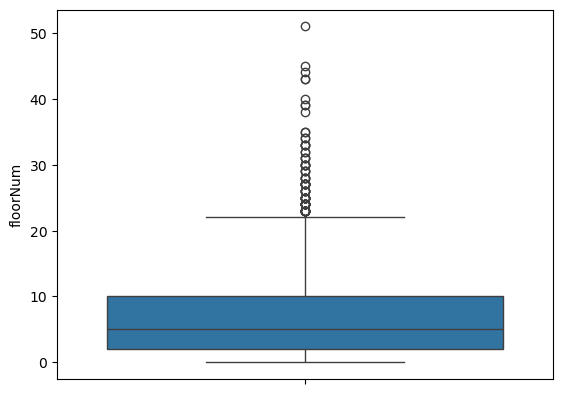

In [12]:
sns.boxplot(df['floorNum'])
plt.show()

In [13]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [14]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [15]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,super_built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 47,2.40,3,3,0,0.0,Moderately Old,2992.86,0,0,0,0,0,1,22,Low,Low Floor
1,flat,sector 65,2.36,3,3,3,2.0,Relatively New,1650.00,1,1,0,0,0,1,136,Medium,Low Floor
2,flat,sector 111,2.25,3,3,2,12.0,Relatively New,1700.05,0,0,0,0,0,0,101,Medium,High Floor
3,flat,sector 71,0.60,2,2,1,5.0,Relatively New,599.98,0,0,0,1,0,0,59,Medium,Mid Floor
4,flat,sector 2,1.40,3,3,3+,8.0,Moderately Old,1780.03,0,0,0,0,0,0,92,Medium,Mid Floor


In [16]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [17]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,super_built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 47,2.40,3,3,0,Moderately Old,2992.86,0,0,0,0,0,1,Low,Low Floor
1,flat,sector 65,2.36,3,3,3,Relatively New,1650.00,1,1,0,0,0,1,Medium,Low Floor
2,flat,sector 111,2.25,3,3,2,Relatively New,1700.05,0,0,0,0,0,0,Medium,High Floor
3,flat,sector 71,0.60,2,2,1,Relatively New,599.98,0,0,0,1,0,0,Medium,Mid Floor
4,flat,sector 2,1.40,3,3,3+,Moderately Old,1780.03,0,0,0,0,0,0,Medium,Mid Floor


#### Ordinal Encoder for changing aplhabets to number

In [18]:
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()
categorical_cols = train_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)
    
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [19]:
categorical_cols

Index(['property_type', 'sector', 'balcony', 'agePossession',
       'luxury_category', 'floor_category'],
      dtype='object')

In [20]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,super_built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,53.0,3,3,0.0,0.0,2992.86,0,0,0,0,0,1,1.0,1.0
1,0.0,73.0,3,3,3.0,3.0,1650.00,1,1,0,0,0,1,2.0,1.0
2,0.0,15.0,3,3,2.0,3.0,1700.05,0,0,0,0,0,0,2.0,0.0
3,0.0,82.0,2,2,1.0,3.0,599.98,0,0,0,1,0,0,2.0,2.0
4,0.0,25.0,3,3,4.0,0.0,1780.03,0,0,0,0,0,0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3509,0.0,97.0,2,2,3.0,3.0,1670.99,0,0,0,0,0,0,1.0,0.0
3510,0.0,55.0,3,3,3.0,3.0,2032.98,0,0,0,0,1,0,1.0,0.0
3511,0.0,97.0,2,2,3.0,3.0,1639.99,0,0,0,0,1,0,1.0,2.0
3512,0.0,44.0,4,4,3.0,3.0,2190.99,0,0,0,0,0,1,2.0,0.0


In [21]:
y_label

0       2.40
1       2.36
2       2.25
3       0.60
4       1.40
        ... 
3509    1.20
3510    2.35
3511    1.05
3512    1.67
3513    1.01
Name: price, Length: 3514, dtype: float64

### `Technique 1` - Correlation Analysis

<Axes: >

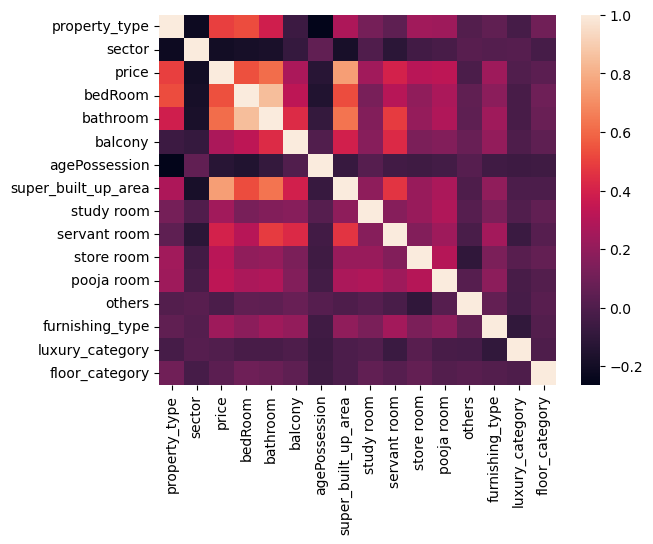

In [22]:
sns.heatmap(data_label_encoded.corr())

In [23]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.202462
1,price,1.000000
2,bedRoom,0.537817
3,bathroom,0.613176
4,balcony,0.275125
5,agePossession,-0.126043
6,super_built_up_area,0.748542
7,study room,0.243734
8,servant room,0.401059
9,store room,0.313457


### `Technique 2` - Random Forest Feature Importance

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,super_built_up_area,0.640224
0,property_type,0.114621
1,sector,0.105287
2,bedRoom,0.027830
8,servant room,0.021433
3,bathroom,0.021003
4,balcony,0.015179
5,agePossession,0.012754
12,furnishing_type,0.010055
13,luxury_category,0.007954


### `Technique 3` - Gradient Boosting Feature importances

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,super_built_up_area,0.672821
1,sector,0.118271
0,property_type,0.108014
3,bathroom,0.038126
2,bedRoom,0.025529
8,servant room,0.021060
12,furnishing_type,0.004517
9,store room,0.002599
4,balcony,0.002242
5,agePossession,0.001733


### `Technique 4` - Permutation Importance

In [26]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,super_built_up_area,0.776844
0,property_type,0.256819
1,sector,0.175638
8,servant room,0.023963
2,bedRoom,0.017616
3,bathroom,0.015733
4,balcony,0.009107
5,agePossession,0.004478
13,luxury_category,0.002634
7,study room,0.002305


### `Technique 5` - LASSO

In [27]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,super_built_up_area,1.415853
0,property_type,0.734330
3,bathroom,0.442154
9,store room,0.179164
12,furnishing_type,0.162803
7,study room,0.140170
8,servant room,0.100839
10,pooja room,0.070897
13,luxury_category,0.054944
5,agePossession,0.000000


### `Technique 6` - RFE

In [28]:
from sklearn.feature_selection import RFE

estimator = RandomForestRegressor()

selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

selected_features = X_label.columns[selector_label.support_]

selected_coefficients = selector_label.estimator_.feature_importances_

fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
6,super_built_up_area,0.645565
0,property_type,0.112586
1,sector,0.104061
2,bedRoom,0.026639
3,bathroom,0.021893
8,servant room,0.020507
4,balcony,0.014247
5,agePossession,0.012523
12,furnishing_type,0.011143
13,luxury_category,0.006974


### `Technique 7` - Linear Regression Weights

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
6,super_built_up_area,1.418469
0,property_type,0.755035
3,bathroom,0.514768
9,store room,0.181592
12,furnishing_type,0.172680
7,study room,0.146215
8,servant room,0.101793
10,pooja room,0.075861
13,luxury_category,0.066673
5,agePossession,0.005546


### `Technique 8` - SHAP

In [31]:
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[-6.57436180e-01,  3.50907669e-01,  8.15615663e-04, ...,
        -6.11208875e-02,  2.04534190e-02, -3.53388019e-02],
       [-2.14369890e-01,  8.39652154e-01, -8.05485758e-03, ...,
        -7.54210946e-03,  6.59707761e-03, -2.07063577e-02],
       [-1.51659325e-01,  2.34841157e-01,  1.32282353e-04, ...,
        -1.40694388e-02,  6.89018041e-03,  4.11157833e-02],
       ...,
       [-1.98866123e-01, -3.69335297e-01, -5.02571078e-02, ...,
        -1.49547149e-02, -2.41320292e-03, -2.05872532e-03],
       [-3.99215164e-01, -9.55869952e-02,  5.98141007e-03, ...,
         7.55638792e-03, -6.83809165e-03,  2.57034781e-02],
       [-2.26667121e-01, -1.80026273e-01, -7.10543196e-02, ...,
         2.76668432e-03, -2.90667608e-03, -1.63232723e-02]])

In [32]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,super_built_up_area,1.179241
0,property_type,0.464656
1,sector,0.380679
8,servant room,0.083391
3,bathroom,0.072233
2,bedRoom,0.053788
4,balcony,0.041339
12,furnishing_type,0.028721
5,agePossession,0.023209
14,floor_category,0.021870


In [33]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [34]:
final_fi_df


,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.202462,0.105287,0.118271,0.175638,-0.044788,0.104061,-0.054040,0.380679
bedRoom,0.537817,0.027830,0.025529,0.017616,-0.235351,0.026639,-0.317600,0.053788
bathroom,0.613176,0.021003,0.038126,0.015733,0.442154,0.021893,0.514768,0.072233
balcony,0.275125,0.015179,0.002242,0.009107,-0.039977,0.014247,-0.059114,0.041339
agePossession,-0.126043,0.012754,0.001733,0.004478,0.000000,0.012523,0.005546,0.023209
super_built_up_area,0.748542,0.640224,0.672821,0.776844,1.415853,0.645565,1.418469,1.179241
study room,0.243734,0.004828,0.001712,0.002305,0.140170,0.005048,0.146215,0.010533
servant room,0.401059,0.021433,0.021060,0.023963,0.100839,0.020507,0.101793,0.083391
store room,0.313457,0.004354,0.002599,0.000634,0.179164,0.004240,0.181592,0.009061


In [35]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [36]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
super_built_up_area    0.713079
sector                 0.147059
bathroom               0.028733
servant room           0.027436
bedRoom                0.026979
balcony                0.013175
agePossession          0.009356
furnishing_type        0.008825
luxury_category        0.005842
floor_category         0.005756
study room             0.004146
pooja room             0.003717
store room             0.003580
others                 0.002317
dtype: float64

### to drop  'store room', 'pooja room', 'study room', 'others'
### we have to prove that accuracy will increase

In [37]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,super_built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,53.0,3,3,0.0,0.0,2992.86,0,0,0,0,0,1,1.0,1.0
1,0.0,73.0,3,3,3.0,3.0,1650.00,1,1,0,0,0,1,2.0,1.0
2,0.0,15.0,3,3,2.0,3.0,1700.05,0,0,0,0,0,0,2.0,0.0
3,0.0,82.0,2,2,1.0,3.0,599.98,0,0,0,1,0,0,2.0,2.0
4,0.0,25.0,3,3,4.0,0.0,1780.03,0,0,0,0,0,0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3509,0.0,97.0,2,2,3.0,3.0,1670.99,0,0,0,0,0,0,1.0,0.0
3510,0.0,55.0,3,3,3.0,3.0,2032.98,0,0,0,0,1,0,1.0,0.0
3511,0.0,97.0,2,2,3.0,3.0,1639.99,0,0,0,0,1,0,1.0,2.0
3512,0.0,44.0,4,4,3.0,3.0,2190.99,0,0,0,0,0,1,2.0,0.0


#### With all the cols

In [38]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2',n_jobs=-1)

In [39]:
scores.mean()

0.8300423545957425

#### After droping the columns

In [41]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['store room','pooja room','study room','others']), y_label, cv=5, scoring='r2',n_jobs=-1)

In [42]:
scores.mean()

0.8306765264427337

#### Accuracy is increased hence we can drop these columns

### Convert it into final data frame to Train Our Models

In [44]:
df_final = train_df.drop(columns=['store room','pooja room','study room','others'])

In [45]:
df_final['servant room'] = df_final['servant room'].replace({0:'No',1:'Yes'})

In [46]:
df_final['furnishing_type'] = df_final['furnishing_type'].replace({0.0:'unfurnished',1.0:'semifurnished',2.0:'furnished'})

In [47]:
df_final

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,super_built_up_area,servant room,furnishing_type,luxury_category,floor_category
0,flat,sector 47,2.40,3,3,0,Moderately Old,2992.86,No,semifurnished,Low,Low Floor
1,flat,sector 65,2.36,3,3,3,Relatively New,1650.00,Yes,semifurnished,Medium,Low Floor
2,flat,sector 111,2.25,3,3,2,Relatively New,1700.05,No,unfurnished,Medium,High Floor
3,flat,sector 71,0.60,2,2,1,Relatively New,599.98,No,unfurnished,Medium,Mid Floor
4,flat,sector 2,1.40,3,3,3+,Moderately Old,1780.03,No,unfurnished,Medium,Mid Floor
...,...,...,...,...,...,...,...,...,...,...,...,...
3509,flat,sector 85,1.20,2,2,3,Relatively New,1670.99,No,unfurnished,Low,High Floor
3510,flat,sector 49,2.35,3,3,3,Relatively New,2032.98,No,unfurnished,Low,High Floor
3511,flat,sector 85,1.05,2,2,3,Relatively New,1639.99,No,unfurnished,Low,Mid Floor
3512,flat,sector 37d,1.67,4,4,3,Relatively New,2190.99,No,semifurnished,Medium,High Floor


In [48]:
df_final = df_final.drop(index=[1030,1073,3070])

In [49]:
df_final.to_csv('gurgaon_properties_post_feature_selection.csv',index=False)